In [1]:
import sys
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from langchain_core.messages import HumanMessage,AIMessage,SystemMessage,BaseMessage
from langchain_core.output_parsers import StrOutputParser,PydanticOutputParser
from langchain_core.prompts import PromptTemplate,ChatPromptTemplate
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph.message import add_messages
sys.path.insert(1, r'D:\Notebooks\LLM\env')
from enviorment import load_env
import os 
load_env()
#model =ChatOpenAI()
from langgraph.graph import StateGraph,START, END

from typing import TypedDict,Annotated,Literal
from langgraph.checkpoint.memory import InMemorySaver
import operator
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults
from pydantic import BaseModel,Field
from langgraph.types import interrupt,Command
from langgraph.checkpoint.memory import MemorySaver


In [2]:
model=ChatGoogleGenerativeAI(
    model="gemini-2.5-flash-lite",   # or gemini-2.0-pro, 1.5-pro, etc.
    temperature=0.2
)

In [ ]:
from langgraph.graph import StateGraph, END

# Shared State
class State(dict):
    result:str
    user_input :str
    next :Literal['order_agent','refund_agent']
    order_id: int
# -----------------------------------------
# CHILD GRAPH 1: ORDER STATUS AGENT
# -----------------------------------------
order_graph = StateGraph(State)

def order_start(state):
    state["result"] = f"Your order #{state['order_id']} is on the way 🚚"
    return state

order_graph.add_node("order_start", order_start)
order_graph.set_entry_point("order_start")


# -----------------------------------------
# CHILD GRAPH 2: REFUND AGENT
# -----------------------------------------
refund_graph = StateGraph(State)

def refund_start(state):
    state["result"] = f"Refund for order #{state['order_id']} has been initiated 💸"
    return state

refund_graph.add_node("refund_start", refund_start)
refund_graph.set_entry_point("refund_start")


# -----------------------------------------
# PARENT GRAPH (Dispatcher Agent)
# -----------------------------------------
parent = StateGraph(State)

# Step 1: Parent decides which child graph to call
def detect_intent(state):
    text = state["user_input"].lower()

    if "refund" in text:
        state["next"] = "refund_agent"
    else:
        state["next"] = "order_agent"

    return state

parent.add_node("detect_intent", detect_intent)
parent.set_entry_point("detect_intent")

# Add child graphs into parent BEFORE compilation

def run_order_graph(state):
    compiled_child = order_graph.compile()
    return compiled_child.invoke(state)
def run_refund_graph(state):
    compiled_child = refund_graph.compile()
    return compiled_child.invoke(state)

#parent.add_node("order_agent", order_graph)
parent.add_node("order_agent", run_order_graph)
parent.add_node("refund_agent", run_refund_graph)

# Routing
def route(state):
    return state  # no change

parent.add_node("router", route)

parent.add_conditional_edges(
    "detect_intent",
    lambda s: s["next"],     # dynamic routing
    {
        "order_agent": "order_agent",
        "refund_agent": "refund_agent"
    }
)

# After child agent finishes → end
parent.add_edge("order_agent", END) 
parent.add_edge("refund_agent", END)

In [16]:
workflow = parent.compile()

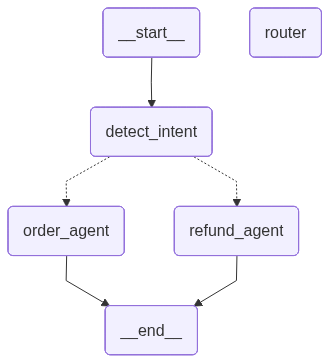

In [17]:
workflow

In [18]:
workflow.invoke({"user_input": "Where is my order?", "order_id": 123})

{'result': 'Your order #123 is on the way 🚚',
 'user_input': 'Where is my order?',
 'next': 'order_agent',
 'order_id': 123}

In [19]:
workflow.invoke({"user_input": "I want a refund", "order_id": 888})

{'result': 'Refund for order #888 has been initiated 💸',
 'user_input': 'I want a refund',
 'next': 'refund_agent',
 'order_id': 888}